In [1]:
import pandas as pd

data = pd.read_csv('user_behavior_data.csv')
data.columns = data.columns.str.strip()
print(data.columns.tolist())
data.head()

['USER ID', 'LANDING PAGE', 'CLICKED APPLY', 'STARTED FORM', 'UPLOADED RESUME', 'SUBMITTED APPLICATION', 'EXIT POINT']


,USER ID,LANDING PAGE,CLICKED APPLY,STARTED FORM,UPLOADED RESUME,SUBMITTED APPLICATION,EXIT POINT
0,1,1,1,1,1,1,Completed
1,2,1,1,1,1,1,Completed
2,3,1,1,1,0,0,Exited during Resume Upload
3,4,1,1,0,0,0,Exited during Application Form
4,5,1,0,0,0,0,Exited after Landing Page


In [2]:
funnel_stages = ['LANDING PAGE', 'CLICKED APPLY', 'STARTED FORM', 'UPLOADED RESUME', 'SUBMITTED APPLICATION']

funnel_counts = data[funnel_stages].sum()
print(funnel_counts)

conversion_rate = (funnel_counts / funnel_counts.iloc[0]) * 100
print(conversion_rate)

LANDING PAGE             50
CLICKED APPLY            36
STARTED FORM             25
UPLOADED RESUME          13
SUBMITTED APPLICATION    11
dtype: int64
LANDING PAGE             100.0
CLICKED APPLY             72.0
STARTED FORM              50.0
UPLOADED RESUME           26.0
SUBMITTED APPLICATION     22.0
dtype: float64


In [3]:
drop_off = funnel_counts.diff().abs()
print(drop_off)

drop_off_percent = (drop_off / funnel_counts.shift(1)) * 100
print(drop_off_percent)

LANDING PAGE              NaN
CLICKED APPLY            14.0
STARTED FORM             11.0
UPLOADED RESUME          12.0
SUBMITTED APPLICATION     2.0
dtype: float64
LANDING PAGE                   NaN
CLICKED APPLY            28.000000
STARTED FORM             30.555556
UPLOADED RESUME          48.000000
SUBMITTED APPLICATION    15.384615
dtype: float64


In [4]:
exit_summary = data['EXIT POINT'].value_counts()
print(exit_summary)

EXIT POINT
Exited after Landing Page         14
Exited during Resume Upload       12
Completed                         11
Exited during Application Form    11
Exited after Resume Upload         2
Name: count, dtype: int64


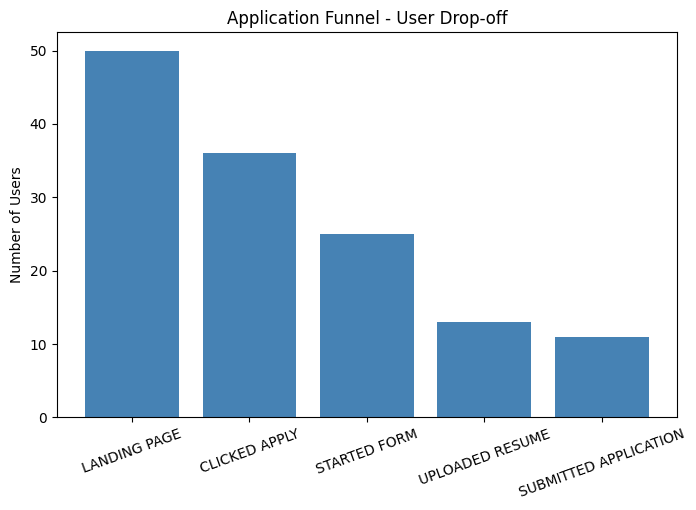

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(funnel_stages, funnel_counts, color='steelblue')
plt.title('Application Funnel - User Drop-off')
plt.ylabel('Number of Users')
plt.xticks(rotation=20)
plt.show()

In [6]:
funnel_counts.to_csv('funnel_analysis_results.csv')
data.to_csv('user_behavior_analyzed.csv', index=False)